# Get dataset spatial coverage and temporal resolution

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import xyzservices as xyz
import coiled
import cartopy
from pyproj import Transformer
import cartopy.crs as ccrs
from cartopy import feature as cfeature
from global_snowmelt_runoff_onset.config import Config, Tile
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import geopandas as gpd
import numpy as np
import zarr
import tqdm
import pandas as pd
import pickle
import os

In [2]:
config = Config('config/global_config_v9.txt')

SAS token is valid until 2026-07-03 00:51 UTC (239.7 hours)
----------------------------------------
Configuration loaded:
config_name = global_config_v9
version = v9
resolution = 0.00072000072000072
bands = vv
mountain_snow_only = False
spatial_chunk_dim_s1_read = 2048
spatial_chunk_dim_s1_process = 512
spatial_chunk_dim_zarr_output = 2048
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 81.099
bbox_bottom = -59.999
wy_start = 2015
wy_end = 2024
low_backscatter_threshold = 0.001
min_monthly_acquisitions = 1
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
extend_search_window_beyond_sdd_days = 16
min_consec_snow_days_for_seasonal_snow = 56
valid_tiles_geojson_path = processing/tile_data/global_tiles_with_seasonal_snow.geojson
tile_results_path = processing/tile_data/tile_results_v9.csv
global_runoff_zarr_store_azure_path = snowmelt/snowmelt_runoff_onset/global_v9.zarr
seasonal_snow_mask_zarr_store_azure_path = snowmelt/snow_cover/global_modis_snow_cover.zarr
season

In [3]:
# cluster = coiled.Cluster(idle_timeout="10 minutes",
#                          #shutdown_on_close=False,
#                          #wait_for_workers=True,
#                          #n_workers=[41,170], # 170
#                          #n_workers=[31,86],
#                          n_workers=2,
#                          #n_workers=8,
#                          #n_workers=10,
#                          worker_memory="256 GB", #coiled.list_instance_types(backend="azure")
#                          #worker_options={"nthreads": 1},
#                          #worker_options={"nthreads": 32},# 16 8 4 oversubscribe?
#                          #scheduler_memory="256 GB",
#                          #scheduler_memory="128 GB",
#                          spot_policy="spot", # spot usually
#                          #software="sar_snowmelt_timing",
#                          environ={"GDAL_DISABLE_READDIR_ON_OPEN": "EMPTY_DIR"},
#                          #container="mcr.microsoft.com/planetary-computer/python:latest",
#                          workspace="uwtacolab",
                         
#                          )

# client = cluster.get_client()

## Load in MODIS dataset and geometries

In [4]:
modis_seasonal_snow_mask_ds = xr.open_zarr(config.seasonal_snow_mask_store, decode_coords="all")
modis_seasonal_snow_mask_ds

<xarray.Dataset> Size: 448GB
Dimensions:               (water_year: 10, y: 43200, x: 86400)
Coordinates:
    spatial_ref           int64 8B ...
  * water_year            (water_year) int64 80B 2015 2016 2017 ... 2023 2024
  * x                     (x) float64 691kB -2.001e+07 -2.001e+07 ... 2.001e+07
  * y                     (y) float64 346kB 1.001e+07 1.001e+07 ... -1.001e+07
Data variables:
    SAD_DOWY              (water_year, y, x) float32 149GB dask.array<chunksize=(1, 2400, 2400), meta=np.ndarray>
    SDD_DOWY              (water_year, y, x) float32 149GB dask.array<chunksize=(1, 2400, 2400), meta=np.ndarray>
    max_consec_snow_days  (water_year, y, x) float32 149GB dask.array<chunksize=(1, 2400, 2400), meta=np.ndarray>
Attributes:
    processed_tiles:  ['h18_v17', 'h15_v16', 'h19_v17', 'h18_v16', 'h17_v17',...

In [5]:
world_gdf = gpd.read_file(
    "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
)
greenland_gdf = world_gdf[world_gdf['ADMIN'] == 'Greenland']
greenland_proj_gdf = greenland_gdf.to_crs(modis_seasonal_snow_mask_ds.rio.crs)
greenland_proj_gdf['geometry'] = greenland_proj_gdf.simplify(100)

In [6]:
# read from shapefile in geometries folder, in canada_poly.zip
canadian_archipelago_gdf = gpd.read_file("data/canada_poly.zip")
canadian_archipelago_proj_gdf = canadian_archipelago_gdf.to_crs(modis_seasonal_snow_mask_ds.rio.crs)
canadian_archipelago_proj_gdf['geometry'] = canadian_archipelago_proj_gdf.simplify(100)

In [7]:
russia_gdf = world_gdf[world_gdf['ADMIN'] == 'Russia']
russia_proj_gdf = russia_gdf.to_crs(modis_seasonal_snow_mask_ds.rio.crs)
# filter out all but the largest polygon by area, you can access like geom.area in russia_proj_gdf.geometry.iloc[0].geoms to get the individual polygons, and then calculate area for each and filter out all but the largest one. The largest one is the mainland, the second largest one is the russian arctic archipelago, and the rest are small islands that we can ignore for this analysis.
russia_proj_gdf = russia_proj_gdf.explode(index_parts=False)
russia_proj_gdf['area'] = russia_proj_gdf.geometry.area
russia_proj_gdf = russia_proj_gdf.sort_values('area', ascending=False).reset_index(drop=True)
russia_proj_gdf['number'] = russia_proj_gdf.index
# remove 0 and 1, which are the mainland and the russian arctic archipelago, respectively
russia_proj_gdf = russia_proj_gdf[russia_proj_gdf['number'] > 1]
# remove all below latitude of 70 N, first convert 70N to y location using transform, not cartopy but pyproj
transformer = Transformer.from_crs("EPSG:4326", modis_seasonal_snow_mask_ds.rio.crs, always_xy=True)
y_coord = transformer.transform(0, 70)
russian_archipelago_proj_gdf = russia_proj_gdf[russia_proj_gdf.geometry.centroid.y > y_coord[1]]
russian_archipelago_proj_gdf['geometry'] = russian_archipelago_proj_gdf.simplify(100)

/home/eric/miniconda3/envs/new_global_snowmelt_runoff_onset/lib/python3.13/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: >

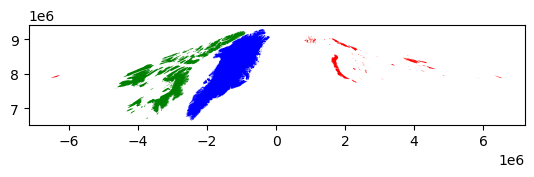

In [8]:
f,ax=plt.subplots()
greenland_proj_gdf.plot(ax=ax, color='blue')
canadian_archipelago_proj_gdf.plot(ax=ax, color='green')
russian_archipelago_proj_gdf.plot(ax=ax, color='red')

## Get MODIS observable seasonal snow extent

In [ ]:
results_list = []

# Get the MODIS data bounds
modis_ds = modis_seasonal_snow_mask_ds['max_consec_snow_days'].sel(y=slice(None, -0.65E7))

# Get y and x coordinate arrays
y_coords = modis_ds.y.values
x_coords = modis_ds.x.values

# MODIS pixel area in km^2
modis_pixel_area_km2 = (modis_ds.rio.resolution()[0] / 1000) ** 2

# Initialize area tracking
water_year_areas = {wy: 0.0 for wy in modis_seasonal_snow_mask_ds.water_year.values}
median_composite_area = 0.0

# Process in y-coordinate bands to avoid memory issues
y_band_size = 500  # Process 2000 rows at a time
n_y = len(y_coords)

print("\n=== Processing MODIS data (all water years + 10-year composite) ===")

for i in tqdm.tqdm(range(0, n_y, y_band_size)):
    end_idx = min(i + y_band_size, n_y)
    
    # Get this y-coordinate band for ALL water years at once
    y_band_all_years = modis_ds.isel(y=slice(i, end_idx))
    
    # Clip out regions (apply to all years at once)
    y_band_clipped = y_band_all_years.rio.clip(
        greenland_proj_gdf.geometry, 
        drop=False, 
        invert=True
    )
    y_band_clipped = y_band_clipped.rio.clip(
        canadian_archipelago_proj_gdf.geometry,
        drop=False,
        invert=True
    )
    y_band_clipped = y_band_clipped.rio.clip(
        russian_archipelago_proj_gdf.geometry,
        drop=False,
        invert=True
    )

    
    # Create binary mask for all years (1 = seasonal snow, 0 = no seasonal snow)
    modis_binary = xr.where(y_band_clipped >= 56, 1, 0)
    
    # Calculate per-year areas
    band_snow_counts = modis_binary.sum(dim=['x', 'y']).compute()
    
    for wy in modis_seasonal_snow_mask_ds.water_year.values:
        band_area = float(band_snow_counts.sel(water_year=wy).values) * modis_pixel_area_km2
        water_year_areas[wy] += band_area
    
    # Calculate 10-year composite (pixels with ≥3 years of snow)
    years_with_snow = modis_binary.sum(dim='water_year').compute()
    composite_pixels = (years_with_snow >= 3).sum().values
    band_composite_area = float(composite_pixels) * modis_pixel_area_km2
    median_composite_area += band_composite_area
    
    # Progress update
    print(f"  Y-band {i:5d}-{end_idx:5d}: Composite area so far: {median_composite_area:12,.0f} km²")
    
    del y_band_all_years, y_band_clipped, modis_binary, band_snow_counts, years_with_snow


In [ ]:
rows = []
for wy in modis_seasonal_snow_mask_ds.water_year.values:
    rows.append({
        'water_year': int(wy),
        'modis_snow_area_km2': water_year_areas[wy],
    })
    print(f"  WY {wy}: {water_year_areas[wy]:,.0f} km²")

rows.append({
    'water_year': 'composite',
    'modis_snow_area_km2': median_composite_area,
})
print(f"\n10-year median composite area (≥3 years snow): {median_composite_area:,.0f} km²")

coverage_df = pd.DataFrame(rows)
coverage_df

In [ ]:
coverage_df.to_csv('results/modis_coverage_per_water_year.csv', index=False)

## Get snowmelt runoff onset dataset spatial coverage and temporal resolution

In [ ]:
global_ds = xr.open_zarr(
    config.global_runoff_store, 
    consolidated=True, 
    decode_coords='all',
)
# global_ds = xr.open_zarr(
#     "../../dataset/global_snowmelt_runoff_onset.zarr", 
#     decode_coords="all", 
#     consolidated=True
# )

# Calculate pixel areas for EPSG:4326
km_per_degree = 111.32

lat_res = abs(float(global_ds.latitude[1] - global_ds.latitude[0]))
lon_res = abs(float(global_ds.longitude[1] - global_ds.longitude[0]))

lats = global_ds.latitude.values

pixel_area_per_lat = (
    (lat_res * km_per_degree) * 
    (lon_res * km_per_degree * np.cos(np.deg2rad(lats)))
)

# Checkpoint file
checkpoint_file = 'results/runoff_checkpoint.pkl'

# Load or initialize
if os.path.exists(checkpoint_file):
    with open(checkpoint_file, 'rb') as f:
        checkpoint = pickle.load(f)
    water_year_areas = checkpoint['water_year_areas']
    median_total_area = checkpoint['median_total_area']
    water_year_temporal_res_sum = checkpoint['water_year_temporal_res_sum']
    water_year_temporal_res_count = checkpoint['water_year_temporal_res_count']
    median_temporal_res_sum = checkpoint['median_temporal_res_sum']
    median_temporal_res_count = checkpoint['median_temporal_res_count']
    start_idx = checkpoint['next_idx']
    print(f"Resuming from band {start_idx}")
else:
    water_year_areas = {wy: 0.0 for wy in global_ds.water_year.values}
    median_total_area = 0.0
    water_year_temporal_res_sum = {wy: 0.0 for wy in global_ds.water_year.values}
    water_year_temporal_res_count = {wy: 0 for wy in global_ds.water_year.values}
    median_temporal_res_sum = 0.0
    median_temporal_res_count = 0
    start_idx = 0
    print("Starting fresh")

lat_band_size = 50
n_lats = len(lats)

print("\n=== Processing runoff onset data ===")

for i in tqdm.tqdm(range(start_idx, n_lats, lat_band_size)):
    end_idx = min(i + lat_band_size, n_lats)
    pixel_areas_band = pixel_area_per_lat[i:end_idx]

    # temporal_resolution is non-null exactly where runoff_onset is non-null —
    # use it directly as both the valid mask and the value, no need to load runoff_onset.
    temporal_res_band = global_ds['temporal_resolution'].isel(latitude=slice(i, end_idx)).compute()
    valid_mask_all_years = temporal_res_band.notnull()

    # --- Spatial coverage + temporal resolution per water year ---
    valid_counts_per_year = valid_mask_all_years.sum(dim='longitude')
    tr_sum_per_wy = temporal_res_band.sum(dim=['latitude', 'longitude'])
    tr_count_per_wy = valid_counts_per_year.sum(dim='latitude')

    for wy in global_ds.water_year.values:
        water_year_areas[wy] += float((valid_counts_per_year.sel(water_year=wy).values * pixel_areas_band).sum())
        water_year_temporal_res_sum[wy] += float(tr_sum_per_wy.sel(water_year=wy))
        water_year_temporal_res_count[wy] += int(tr_count_per_wy.sel(water_year=wy))

    # --- Median composite spatial coverage + temporal resolution ---
    # Same logic: temporal_resolution_median is non-null exactly where runoff_onset_median is non-null.
    median_temporal_res_band = global_ds['temporal_resolution_median'].isel(latitude=slice(i, end_idx)).compute()
    median_valid_counts = median_temporal_res_band.notnull().sum(dim='longitude')
    median_total_area += float((median_valid_counts.values * pixel_areas_band).sum())
    median_temporal_res_sum += float(median_temporal_res_band.sum())
    median_temporal_res_count += int(median_valid_counts.sum())

    # Save checkpoint after every band
    with open(checkpoint_file, 'wb') as f:
        pickle.dump({
            'water_year_areas': water_year_areas,
            'median_total_area': median_total_area,
            'water_year_temporal_res_sum': water_year_temporal_res_sum,
            'water_year_temporal_res_count': water_year_temporal_res_count,
            'median_temporal_res_sum': median_temporal_res_sum,
            'median_temporal_res_count': median_temporal_res_count,
            'next_idx': end_idx
        }, f)

    print(f"  Lat band {i:5d}-{end_idx:5d}: Median area: {median_total_area:12,.0f} km²")

    del temporal_res_band, median_temporal_res_band

print("\nProcessing complete!")

for wy in global_ds.water_year.values:
    print(f"  WY {wy}: {water_year_areas[wy]:,.0f} km²")
print(f"\nMedian composite area: {median_total_area:,.0f} km²")

os.remove(checkpoint_file)

Resuming from band 131950

=== Processing runoff onset data ===


  0%|          | 1/1281 [00:09<3:20:44,  9.41s/it]

  Lat band 131950-132000: Median area:   36,166,017 km²


  0%|          | 2/1281 [00:17<3:03:16,  8.60s/it]

  Lat band 132000-132050: Median area:   36,166,041 km²


...

  Lat band 195850-195900: Median area:   36,761,636 km²


100%|█████████▉| 1280/1281 [2:35:30<00:07,  7.22s/it]

  Lat band 195900-195950: Median area:   36,761,636 km²


100%|██████████| 1281/1281 [2:35:35<00:00,  7.29s/it]

  Lat band 195950-195970: Median area:   36,761,636 km²

Processing complete!
  WY 2015: 9,779,036 km²
  WY 2016: 8,690,212 km²
  WY 2017: 35,539,626 km²
  WY 2018: 31,639,543 km²
  WY 2019: 31,818,050 km²
  WY 2020: 32,028,753 km²
  WY 2021: 32,430,436 km²
  WY 2022: 16,006,632 km²
  WY 2023: 17,542,408 km²
  WY 2024: 15,702,889 km²

Median composite area: 36,761,636 km²


In [10]:
rows = []
for wy in global_ds.water_year.values:
    rows.append({
        'water_year': int(wy),
        'runoff_onset_area_km2': water_year_areas[wy],
        'avg_temporal_resolution_days': water_year_temporal_res_sum[wy] / water_year_temporal_res_count[wy],
    })
    print(f"  WY {wy}: {water_year_areas[wy]:,.0f} km²  |  avg temporal res: {water_year_temporal_res_sum[wy] / water_year_temporal_res_count[wy]:.1f} days")

rows.append({
    'water_year': 'composite',
    'runoff_onset_area_km2': median_total_area,
    'avg_temporal_resolution_days': median_temporal_res_sum / median_temporal_res_count,
})
print(f"\nMedian composite area: {median_total_area:,.0f} km²  |  avg temporal res: {median_temporal_res_sum / median_temporal_res_count:.1f} days")

results_df = pd.DataFrame(rows)
results_df

  WY 2015: 9,779,036 km²  |  avg temporal res: 16.5 days
  WY 2016: 8,690,212 km²  |  avg temporal res: 16.1 days
  WY 2017: 35,539,626 km²  |  avg temporal res: 9.5 days
  WY 2018: 31,639,543 km²  |  avg temporal res: 9.7 days
  WY 2019: 31,818,050 km²  |  avg temporal res: 9.1 days
  WY 2020: 32,028,753 km²  |  avg temporal res: 9.6 days
  WY 2021: 32,430,436 km²  |  avg temporal res: 8.6 days
  WY 2022: 16,006,632 km²  |  avg temporal res: 8.9 days
  WY 2023: 17,542,408 km²  |  avg temporal res: 8.5 days
  WY 2024: 15,702,889 km²  |  avg temporal res: 10.6 days

Median composite area: 36,761,636 km²  |  avg temporal res: 9.5 days


,water_year,runoff_onset_area_km2,avg_temporal_resolution_days
0,2015,9.779036e+06,16.509566
1,2016,8.690212e+06,16.067830
2,2017,3.553963e+07,9.451414
3,2018,3.163954e+07,9.650621
4,2019,3.181805e+07,9.070107
5,2020,3.202875e+07,9.576729
6,2021,3.243044e+07,8.597721
7,2022,1.600663e+07,8.932358
8,2023,1.754241e+07,8.506939
9,2024,1.570289e+07,10.581301


In [11]:
results_df.to_csv('results/runoff_onset_coverage_and_temporal_res_per_water_year.csv', index=False)

## Merge results

In [51]:
modis_df = pd.read_csv('results/modis_coverage_per_water_year.csv', dtype={'water_year': str})
results_df = pd.read_csv('results/runoff_onset_coverage_and_temporal_res_per_water_year.csv', dtype={'water_year': str})

results_df = results_df.merge(modis_df, on='water_year', how='left')

results_df['percent_coverage'] = (
    results_df['runoff_onset_area_km2'] / 
    results_df['modis_snow_area_km2'] * 100
)

results_df = results_df[[
    'water_year',
    'runoff_onset_area_km2',
    'modis_snow_area_km2',
    'percent_coverage',
    'avg_temporal_resolution_days'
]]

results_df

,water_year,runoff_onset_area_km2,modis_snow_area_km2,percent_coverage,avg_temporal_resolution_days
0,2015,9.779036e+06,3.539653e+07,27.627102,16.509566
1,2016,8.690212e+06,3.576238e+07,24.299870,16.067830
2,2017,3.553963e+07,3.769205e+07,94.289444,9.451414
3,2018,3.163954e+07,3.589717e+07,88.139378,9.650621
4,2019,3.181805e+07,3.651766e+07,87.130573,9.070107
5,2020,3.202875e+07,3.599250e+07,88.987299,9.576729
6,2021,3.243044e+07,3.600390e+07,90.074788,8.597721
7,2022,1.600663e+07,3.631745e+07,44.074218,8.932358
8,2023,1.754241e+07,3.663490e+07,47.884413,8.506939
9,2024,1.570289e+07,3.604374e+07,43.566199,10.581301


In [52]:
# this table corresponds to Table 1 in the paper, with columns water year, spatial coverage, observable seasonal snow extent, coverage, average temporal resolution
results_df.to_csv('results/complete_spatial_coverage_and_temporal_res_per_water_year.csv', index=False)

In [53]:
# now we can create a seasonal_snow_extent column which is the sum of the modis_snow_area_km2 column
# and the excluded areas calculated in /home/eric/repos/global_snowmelt_runoff_onset/dataset_evaluation/calculate_spatial_coverage_and_temporal_resolution/calculate_spatial_coverage_and_temporal_resolution.ipynb
results_revised_df = results_df.copy()
# now modify results_df to add a new column called total_seasonal_snow_extent_km2 which is the sum of modis_snow_area_km2 and the Total Excluded Area from seasonal_snow_excluded_area_df
results_revised_df['total_seasonal_snow_extent_km2'] = results_revised_df['modis_snow_area_km2'] + seasonal_snow_excluded_area_df.loc[seasonal_snow_excluded_area_df['Region'] == 'Total Excluded Area', 'Snow Area (km^2)'].values[0]
# now reorder the columns to have total_seasonal_snow_extent_km2 after modis_snow_area_km2
results_revised_df = results_revised_df[[
    'water_year',
    'runoff_onset_area_km2',
    'modis_snow_area_km2',
    'total_seasonal_snow_extent_km2',
    'percent_coverage',
    'avg_temporal_resolution_days'
]]
# rename the percent_coverage column to be percent_coverage_of_modis_snow_area
results_revised_df = results_revised_df.rename(columns={'percent_coverage': 'percent_coverage_of_modis_snow_area'})
# then recalculate the percent_coverage column to be runoff_onset_area_km2 / total_seasonal_snow_extent_km2 * 100
results_revised_df['percent_coverage_of_total_seasonal_snow_extent'] = results_revised_df['runoff_onset_area_km2'] / results_revised_df['total_seasonal_snow_extent_km2'] * 100
# reorder the columns to have percent_coverage_of_total_seasonal_snow_extent after percent_coverage_of_modis_snow_area
results_revised_df = results_revised_df[[
    'water_year',
    'runoff_onset_area_km2',
    'modis_snow_area_km2',
    'total_seasonal_snow_extent_km2',
    'percent_coverage_of_modis_snow_area',
    'percent_coverage_of_total_seasonal_snow_extent',
    'avg_temporal_resolution_days'
]]
results_revised_df

,water_year,runoff_onset_area_km2,modis_snow_area_km2,total_seasonal_snow_extent_km2,percent_coverage_of_modis_snow_area,percent_coverage_of_total_seasonal_snow_extent,avg_temporal_resolution_days
0,2015,9.779036e+06,3.539653e+07,3.705966e+07,27.627102,26.387281,16.509566
1,2016,8.690212e+06,3.576238e+07,3.742551e+07,24.299870,23.220025,16.067830
2,2017,3.553963e+07,3.769205e+07,3.935518e+07,94.289444,90.304830,9.451414
3,2018,3.163954e+07,3.589717e+07,3.756030e+07,88.139378,84.236670,9.650621
4,2019,3.181805e+07,3.651766e+07,3.818079e+07,87.130573,83.335233,9.070107
5,2020,3.202875e+07,3.599250e+07,3.765562e+07,88.987299,85.057022,9.576729
6,2021,3.243044e+07,3.600390e+07,3.766703e+07,90.074788,86.097684,8.597721
7,2022,1.600663e+07,3.631745e+07,3.798058e+07,44.074218,42.144259,8.932358
8,2023,1.754241e+07,3.663490e+07,3.829803e+07,47.884413,45.804990,8.506939
9,2024,1.570289e+07,3.604374e+07,3.770687e+07,43.566199,41.644637,10.581301


In [54]:
results_revised_df.to_csv('results/complete_spatial_coverage_and_temporal_res_per_water_year_REVISED.csv', index=False)